# 10 · KasPintar: Memilih & Mengkalibrasi Model

Kandidat model diambil dari temuan tahap simulasi, lalu **diputuskan oleh data riil**:

| Komponen | Kandidat | Cara memilih |
|---|---|---|
| Forecaster | QuantileMLP (9 kuantil, 5%–99%) untuk total kumulatif 1–14 hari | – |
| Kolaborasi | Local, **FedAvg**, FedProx, FedProx+fine-tune, Clustered FL, (Centralized = batas atas) | **CRPS validasi** |
| Kejujuran | ACI satu sisi per ATM vs **per bank** | coverage di periode uji |

Diffusion **tidak dipakai**: keputusan isi cukup dijawab kuantil total kumulatif, dan di simulasi diffusion
federated meremehkan risiko ekor.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.cash.pipeline import run_atm_case_cached, label, Q_ATM, SERVICE_LEVELS
from fedprob.cash.report import plot_cum_fan
from fedprob.conformal import aci_upper
res = run_atm_case_cached(cache_dir="../results", verbose=False)
print("Sistem KasPintar memakai:", label(res.system))

Sistem KasPintar memakai: Federated (FedAvg) + ACI


## Seleksi model: CRPS validasi vs uji (total 7 hari, lebih kecil lebih baik)

In [3]:
test_crps = res.metrics.groupby("method", sort=False)["CRPS"].mean()
tab = pd.DataFrame({"CRPS validasi": pd.Series(res.extras["val_crps"]), "CRPS uji": test_crps})
tab.rename(index=label).style.format("{:.3f}").highlight_min(axis=0, color="#cde7cd")

,CRPS validasi,CRPS uji
Seasonal naive + kuantil residual,0.520,0.556
Local (tiap bank sendiri),0.426,0.471
Federated (FedAvg),0.379,0.361
Federated (FedProx),0.402,0.416
FedProx + fine-tune per bank,0.391,0.399
Clustered FL,0.384,0.371
Centralized (data digabung),0.375,0.366


**Pelajaran:** di simulasi FedProx yang terbaik, tetapi di data riil **FedAvg** terbaik di antara metode federated
(validasi maupun uji), dan hampir menyamai Centralized. Simulasi memberi hipotesis, data riil yang memutuskan.
Clustered FL tidak menemukan struktur kelompok (silhouette < 0.3), sehingga perilakunya sama dengan FedAvg.

In [4]:
print("silhouette Clustered FL:", {k: round(v, 2) for k, v in res.extras.get("cluster_silhouette", {}).items()})

silhouette Clustered FL: {2: 0.14, 3: 0.05}


## Siapa yang paling diuntungkan kolaborasi? CRPS per bank

In [5]:
m = res.metrics[res.metrics.method.isin(["local", "fedavg", "central"])]
piv = m.groupby(["bank", "method"]).CRPS.mean().unstack()[["local", "fedavg", "central"]]
piv["perbaikan FedAvg vs Local"] = 1 - piv["fedavg"] / piv["local"]
piv.style.format({"local": "{:.3f}", "fedavg": "{:.3f}", "central": "{:.3f}", "perbaikan FedAvg vs Local": "{:.0%}"})

method,local,fedavg,central,perbaikan FedAvg vs Local
bank,,,,
Bank Alfa,0.357,0.376,0.386,-5%
Bank Beta,0.396,0.363,0.360,8%
Bank Delta,0.401,0.364,0.363,9%
Bank Epsilon,0.443,0.385,0.390,13%
Bank Gamma,0.363,0.337,0.343,7%
Bank Zeta,1.592,0.319,0.341,80%


## Kalibrasi: apakah kuantil atas bisa dipercaya?

Proporsi total 7 hari aktual ≤ kuantil-s (semua origin harian periode uji). Idealnya sama dengan s.

In [6]:
sel = res.extras["selected"]
cal = res.metrics[res.metrics.method == sel][[c for c in res.metrics.columns if c.startswith("atas")]].mean()
pd.DataFrame({"tanpa ACI": [cal[f"atas{int(l*100)}"] for l in SERVICE_LEVELS],
              "ACI per bank": [cal[f"atas{int(l*100)}_aci"] for l in SERVICE_LEVELS]},
             index=[f"{l:.0%}" for l in SERVICE_LEVELS]).style.format("{:.1%}")

,tanpa ACI,ACI per bank
90%,81.5%,89.2%
95%,88.9%,94.3%
98%,94.9%,97.6%
99%,97.1%,98.8%


### Hasil negatif: ACI per ATM gagal
ACI per ATM hanya punya ~30 skor terbaru yang saling tumpang tindih (≈ 4 minggu independen). Kuantil 98% tidak
mungkin diestimasi dari data sesedikit itu. Menggabungkan skor **semua ATM dalam satu bank** (data tetap di
bank) menyelesaikan masalah ini.

In [7]:
from fedprob.cash.policy import CYCLE
rows = []
for lv in (0.95, 0.98):
    qi = Q_ATM.index(lv)
    per_atm = [aci_upper(a.val.y, pv[..., qi], a.val.origins, a.test.y, pt[..., qi], a.test.origins, lv)
               for a, pv, pt in zip(res.atms, res.preds_val[sel], res.preds[sel])]
    cov = lambda adj: np.mean([(a.test.y[:, CYCLE - 1] <= q[:, CYCLE - 1]).mean() for a, q in zip(res.atms, adj)])
    rows.append({"target": f"{lv:.0%}", "tanpa ACI": cov([p[..., qi] for p in res.preds[sel]]),
                 "ACI per ATM": cov(per_atm), "ACI per bank": cov(res.aci[sel][lv])})
pd.DataFrame(rows).set_index("target").style.format("{:.1%}")

,tanpa ACI,ACI per ATM,ACI per bank
target,,,
95%,88.9%,90.6%,94.3%
98%,94.9%,88.3%,97.6%


## Contoh forecast: total penarikan kumulatif 14 hari

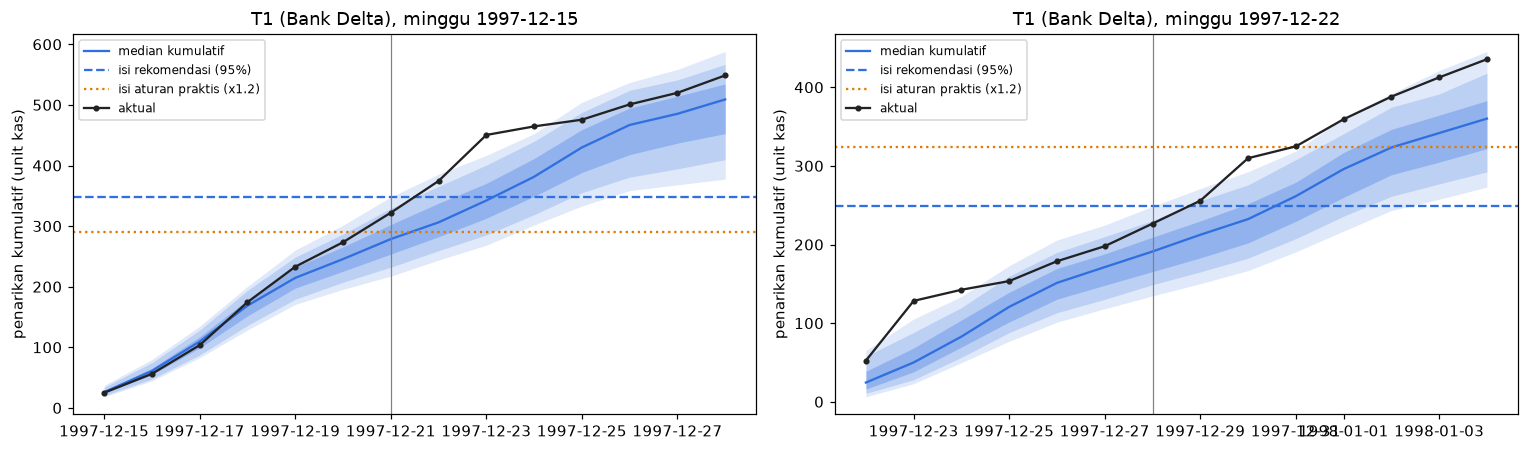

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
plot_cum_fan(res, 0, 2, ax=axes[0])     # minggu biasa
plot_cum_fan(res, 0, 3, ax=axes[1])     # minggu menjelang Natal
plt.tight_layout()

Pita biru adalah rentang kemungkinan total penarikan. Garis putus-putus biru adalah **isi rekomendasi**
(kuantil 95% total 7 hari setelah ACI), garis titik oranye adalah aturan praktis, dan garis hitam adalah
penarikan aktual. Pada minggu menjelang Natal, rentangnya otomatis melebar dan rekomendasi isi naik.